# Risk model experiment: why the fraud label cannot be learned (TQ-023)

Team question TQ-023: on the full 2023 to 2026 history the leak-free risk model and the rules baseline both score ROC AUC 0.50. This notebook lets anyone watch what the model does, which variables it uses, how the label behaves along each of them, and why the result is negative. Everything is computed from `data/lakehouse_full.duckdb` (falls back to the June sample if the full file is missing). `fraud_score` appears only where the leak is shown; it is never a model input.

Run it with `uv run python scripts/notebooks/run_notebook.py notebooks/02_risk_model_experiment.ipynb` or open it in Jupyter from the repo root.

In [1]:
import os, time, warnings
from pathlib import Path
import duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
from sklearn.inspection import permutation_importance
from src.ml.fraud_risk import (FEATURES, FEATURE_PHRASES, NUMERIC, build_features, rules_baseline_score, cost_threshold,
                               load_training_frame, MISSED_FRAUD_COST, UNNECESSARY_VERIFICATION_COST)
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.edgecolor": "#e6e5e1", "font.size": 9})
BLUE, ORANGE, RED, GRAY = "#2a78d6", "#eb6834", "#e34948", "#8a8985"
SOURCE = Path("data/lakehouse_full.duckdb") if Path("data/lakehouse_full.duckdb").exists() else Path("data/lakehouse.duckdb")
con = duckdb.connect(str(SOURCE), read_only=True)
n_rows, n_fraud, d0, d1 = con.execute("SELECT COUNT(*), SUM(CASE WHEN is_fraud THEN 1 ELSE 0 END), MIN(process_date), MAX(process_date) FROM gold_transactions").fetchone()
print(f"source: {SOURCE}  rows: {n_rows:,}  fraud: {n_fraud:,} ({n_fraud/n_rows*100:.3f}%)  period: {d0} to {d1}")

source: data/lakehouse_full.duckdb  rows: 4,425,008  fraud: 4,316 (0.098%)  period: 2023-06-17 to 2026-06-17


## 1. The label and the leak

`is_fraud` is the target. `fraud_score` is a column of the same table that separates the classes almost perfectly: every non-fraud row scores 30 or less. It is a leak (the score was generated from the label), so it is excluded from the model and from the baseline. It is drawn here once, as the reference of what "signal" would look like.

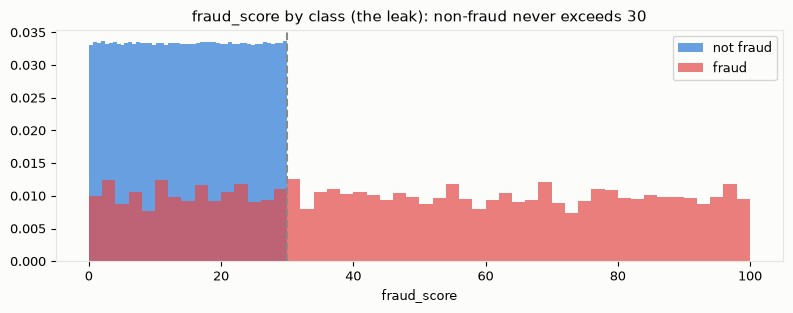

              count       mean   min    max
is_fraud                                   
False     3536426.0  14.997818  0.00  30.00
True         3425.0  49.464485  0.01  99.99


In [2]:
leak = con.execute("SELECT is_fraud, fraud_score FROM gold_transactions WHERE fraud_score IS NOT NULL").df()
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(leak.loc[~leak.is_fraud, "fraud_score"], bins=50, density=True, alpha=0.7, color=BLUE, label="not fraud")
ax.hist(leak.loc[leak.is_fraud, "fraud_score"], bins=50, density=True, alpha=0.7, color=RED, label="fraud")
ax.axvline(30, color=GRAY, ls="--"); ax.set_title("fraud_score by class (the leak): non-fraud never exceeds 30"); ax.set_xlabel("fraud_score"); ax.legend()
plt.tight_layout(); plt.savefig("notebooks/06_fraud_score_leak_full.png", dpi=120); plt.show()
print(leak.groupby("is_fraud")["fraud_score"].describe()[["count", "mean", "min", "max"]])

## 2. Variables the model uses

Only pre-authorization behavior, computed per transaction from the customer's earlier rows (velocity and ratio never look ahead). Nothing here is derived from the label.

In [3]:
tx, customers = load_training_frame(SOURCE)
t0 = time.time(); feats = build_features(tx, customers); print(f"features built for {len(feats):,} rows in {time.time()-t0:.0f} s")
feats["is_fraud"] = feats["is_fraud"].fillna(False).astype(int)
described = pd.DataFrame([{"feature": f, "meaning": FEATURE_PHRASES.get(f, f.replace("channel_", "channel = ").replace("merchant_", "merchant category = "))} for f in FEATURES])
described

features built for 4,425,008 rows in 27 s


,feature,meaning
0,amount_usd,Amount in USD
1,log_amount_usd,Amount in USD (log scale)
2,velocity_24h_count,Charges in the last 24 hours
3,velocity_24h_sum,Amount charged in the last 24 hours
4,velocity_7d_count,Charges in the last 7 days
5,velocity_7d_sum,Amount charged in the last 7 days
6,ratio_to_historical_avg,Amount versus the customer's average
7,is_foreign_country,Charge made outside the customer's country
8,hour_sin,Time of day (processing clock)
9,hour_cos,Time of day (processing clock)


In [4]:
example = pd.concat([feats[feats.is_fraud == 1].head(2), feats[feats.is_fraud == 0].head(2)])
example[["transaction_id", "is_fraud"] + NUMERIC].round(3)

,transaction_id,is_fraud,amount_usd,log_amount_usd,velocity_24h_count,velocity_24h_sum,velocity_7d_count,velocity_7d_sum,ratio_to_historical_avg,is_foreign_country,hour_sin,hour_cos,account_age_days,card_not_present
3101,TRX-Z322GCR4Y47AC3J9YEIP,1,377.47,5.936,0,0.00,0,0.00,0.282,0.0,-1.000,-0.009,418,0.0
3225,TRX-BHFIPSSTXNEMY3MOCEY7,1,2384.00,7.777,0,0.00,0,0.00,1.617,0.0,-0.952,-0.305,1150,1.0
0,TRX-62HQL1RKKYB1WL0WXPNK,0,4969.09,8.511,0,0.00,0,0.00,1.000,0.0,-0.946,-0.326,1160,0.0
1,TRX-51D1KE92W7CNTRN56ABA,0,216.87,5.384,0,63.12,0,63.12,0.044,0.0,0.731,-0.682,1160,1.0


## 3. Does the fraud rate move along any variable?

Each panel bins one variable and draws the fraud rate per bin; the dashed line is the overall rate. A useful variable would show bins clearly above and below the line.

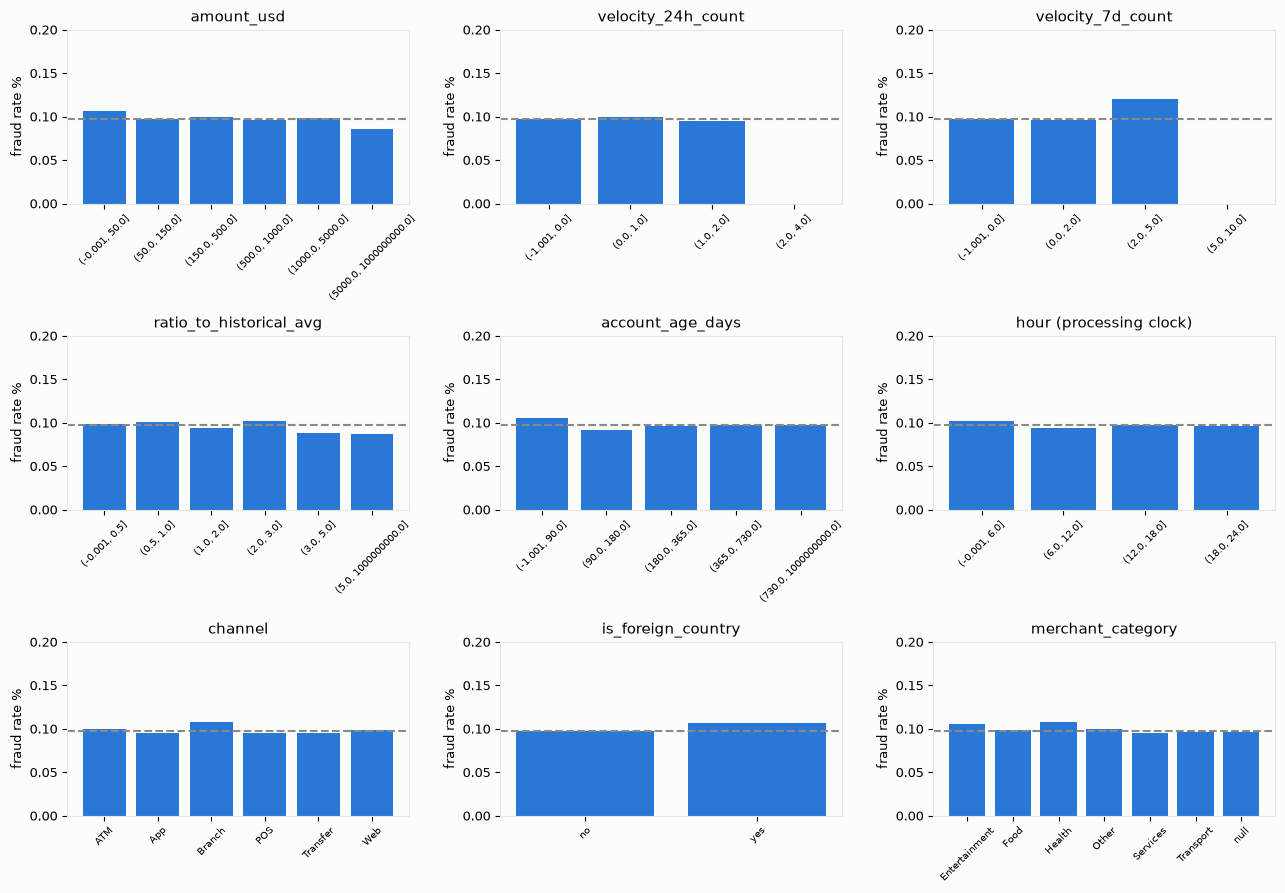

overall fraud rate 0.098%


,variable,bins,min rate %,max rate %,smallest bin
0,amount_usd,6,0.086,0.107,164459
1,velocity_24h_count,4,0.000,0.100,96
2,velocity_7d_count,4,0.000,0.121,15
3,ratio_to_historical_avg,6,0.087,0.102,210036
4,account_age_days,5,0.092,0.105,135610
5,hour (processing clock),4,0.094,0.102,1103294
6,channel,6,0.095,0.108,89159
7,is_foreign_country,2,0.097,0.107,202800
8,merchant_category,7,0.096,0.108,102903


In [5]:
base_rate = feats["is_fraud"].mean() * 100
def bucket(series, bins):
    return pd.cut(series, bins=bins, include_lowest=True, duplicates="drop")
panels = {
    "amount_usd": bucket(feats["amount_usd"], [0, 50, 150, 500, 1000, 5000, 1e9]),
    "velocity_24h_count": bucket(feats["velocity_24h_count"], [-1, 0, 1, 2, 4, 1e9]),
    "velocity_7d_count": bucket(feats["velocity_7d_count"], [-1, 0, 2, 5, 10, 1e9]),
    "ratio_to_historical_avg": bucket(feats["ratio_to_historical_avg"], [0, 0.5, 1, 2, 3, 5, 1e9]),
    "account_age_days": bucket(feats["account_age_days"], [-1, 90, 180, 365, 730, 1e9]),
    "hour (processing clock)": pd.cut(((np.arctan2(feats["hour_sin"], feats["hour_cos"]) / (2*np.pi)) % 1) * 24, bins=[0, 6, 12, 18, 24], include_lowest=True),
    "channel": feats["channel"].fillna("null"),
    "is_foreign_country": feats["is_foreign_country"].map({0.0: "no", 1.0: "yes"}),
    "merchant_category": feats["merchant_category"].fillna("null"),
}
rows = []
fig, axes = plt.subplots(3, 3, figsize=(13, 9)); axes = axes.ravel()
for ax, (name, groups) in zip(axes, panels.items()):
    rate = feats.groupby(groups, observed=True)["is_fraud"].agg(["mean", "size"])
    rate["rate_pct"] = rate["mean"] * 100
    ax.bar([str(i) for i in rate.index], rate["rate_pct"], color=BLUE); ax.axhline(base_rate, color=GRAY, ls="--")
    ax.set_title(name); ax.set_ylabel("fraud rate %"); ax.tick_params(axis="x", rotation=45, labelsize=7); ax.set_ylim(0, max(0.2, rate["rate_pct"].max() * 1.3))
    rows.append({"variable": name, "bins": len(rate), "min rate %": round(rate["rate_pct"].min(), 3), "max rate %": round(rate["rate_pct"].max(), 3), "smallest bin": int(rate["size"].min())})
plt.tight_layout(); plt.savefig("notebooks/07_fraud_rate_by_feature.png", dpi=120); plt.show()
print(f"overall fraud rate {base_rate:.3f}%")
pd.DataFrame(rows)

## 4. How much information each variable carries

Mutual information with the label and the point-biserial correlation, on a random sample. Values are on the scale of a label with no relation to the features (mutual information near zero and correlations within sampling noise).

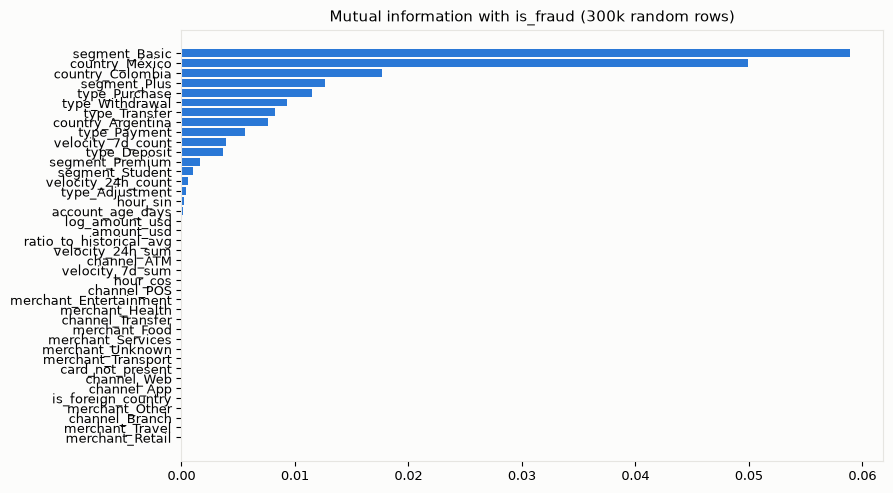

,feature,mutual_information,point_biserial_corr
32,segment_Basic,0.058876,0.002949
27,country_México,0.049908,-0.002683
28,country_Colombia,0.017684,-0.000646
31,segment_Plus,0.012679,-0.001025
34,type_Purchase,0.011498,0.001002
35,type_Withdrawal,0.009343,0.001702
36,type_Transfer,0.008240,-0.002305
29,country_Argentina,0.007630,0.004104
37,type_Payment,0.005567,-0.000689
4,velocity_7d_count,0.003914,-0.002061


In [6]:
from sklearn.feature_selection import mutual_info_classif
sample = feats.sample(n=min(300_000, len(feats)), random_state=7)
discrete = np.array([f.startswith(("channel_", "merchant_")) or f in ("is_foreign_country", "card_not_present") for f in FEATURES])
mi = mutual_info_classif(sample[FEATURES].to_numpy(), sample["is_fraud"].to_numpy(), discrete_features=discrete, random_state=7)
corr = [np.corrcoef(sample[f].astype(float), sample["is_fraud"])[0, 1] for f in FEATURES]
info = pd.DataFrame({"feature": FEATURES, "mutual_information": mi, "point_biserial_corr": corr}).sort_values("mutual_information", ascending=False)
fig, ax = plt.subplots(figsize=(9, 5)); ax.barh(info["feature"][::-1], info["mutual_information"][::-1], color=BLUE); ax.set_title("Mutual information with is_fraud (300k random rows)"); plt.tight_layout(); plt.show()
info.round(6).head(12)

## 5. Model against the rules baseline on a time split

Same pipeline as `src/ml/fraud_risk.py`: split by `process_date` (last 35 percent of days held out), gradient boosting with balanced class weights, threshold chosen on the training split by cost (a missed fraud costs 10 unnecessary verifications). The leaked `fraud_score` is added to the ROC chart as the reference of a real signal; it is not a candidate model.

train 2,869,946 rows (2871 fraud), test from 2025-05-30: 1,555,062 rows (1445 fraud)


trained in 3 s


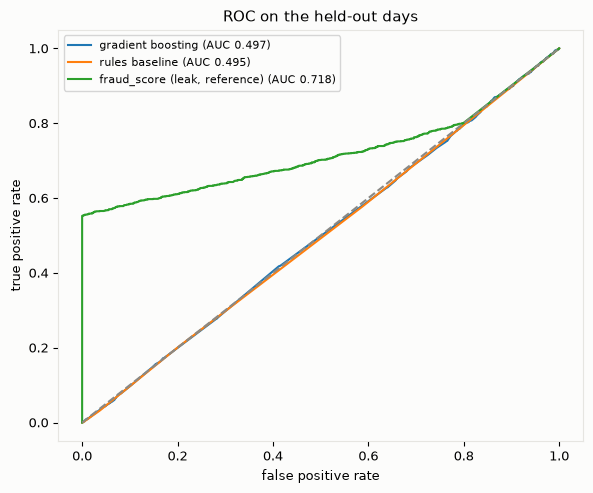

,system,test ROC AUC,test PR AUC,threshold (by train cost),flagged,fraud caught,fraud missed
0,gradient boosting,0.497,0.0009,1.0,0,0,1445
1,rules baseline,0.495,0.0009,1.0,2120,0,1445
2,"fraud_score (leak, reference)",0.718,0.5538,0.3,798,798,647


In [7]:
days = sorted(pd.to_datetime(feats["process_date"]).dt.date.unique())
split_at = days[int(round(len(days) * 0.65))]
is_test = pd.to_datetime(feats["process_date"]).dt.date >= split_at
train_df, test_df = feats[~is_test], feats[is_test]
X_tr, y_tr, X_te, y_te = train_df[FEATURES].to_numpy(), train_df["is_fraud"].to_numpy(), test_df[FEATURES].to_numpy(), test_df["is_fraud"].to_numpy()
print(f"train {len(train_df):,} rows ({y_tr.sum()} fraud), test from {split_at}: {len(test_df):,} rows ({y_te.sum()} fraud)")
t0 = time.time()
model = HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, max_leaf_nodes=15, min_samples_leaf=10, class_weight="balanced", random_state=7).fit(X_tr, y_tr)
print(f"trained in {time.time()-t0:.0f} s")
# the leaked score is fetched apart, joined by transaction id: it is never part of the training frame
leak_scores = con.execute("SELECT transaction_id, fraud_score / 100.0 AS leak FROM gold_transactions").df().set_index("transaction_id")["leak"]  # NULL where the dataset has no score
leak_te, leak_tr = leak_scores.reindex(test_df["transaction_id"]).fillna(0).to_numpy(), leak_scores.reindex(train_df["transaction_id"]).fillna(0).to_numpy()
scores = {"gradient boosting": model.predict_proba(X_te)[:, 1], "rules baseline": rules_baseline_score(test_df), "fraud_score (leak, reference)": leak_te}
table = []
fig, ax = plt.subplots(figsize=(6, 5))
for name, s in scores.items():
    fpr, tpr, _ = roc_curve(y_te, s); ax.plot(fpr, tpr, label=f"{name} (AUC {roc_auc_score(y_te, s):.3f})")
    thr, cost = cost_threshold(y_tr, model.predict_proba(X_tr)[:, 1] if name.startswith("gradient") else (rules_baseline_score(train_df) if name.startswith("rules") else leak_tr))
    flagged = s >= thr
    table.append({"system": name, "test ROC AUC": round(roc_auc_score(y_te, s), 3), "test PR AUC": round(average_precision_score(y_te, s), 4),
                  "threshold (by train cost)": round(thr, 3), "flagged": int(flagged.sum()), "fraud caught": int((flagged & (y_te == 1)).sum()), "fraud missed": int((~flagged & (y_te == 1)).sum())})
ax.plot([0, 1], [0, 1], color=GRAY, ls="--"); ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate"); ax.set_title("ROC on the held-out days"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("notebooks/08_risk_model_roc.png", dpi=120); plt.show()
pd.DataFrame(table)

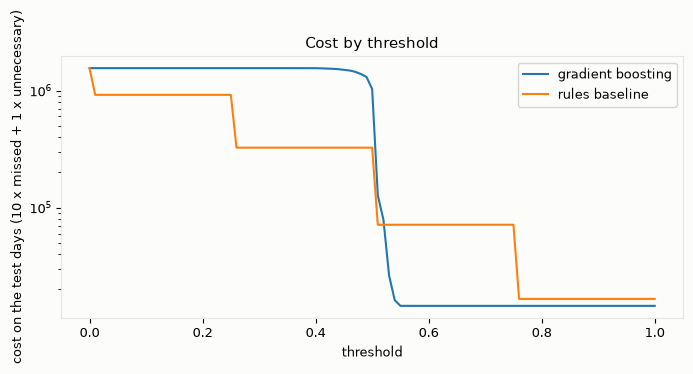

In [8]:
# Cost as a function of the threshold: with no signal, flagging nothing is the cheapest policy under the 10x rule
fig, ax = plt.subplots(figsize=(7, 3.5))
for name in ("gradient boosting", "rules baseline"):
    s = scores[name]; ts = np.linspace(0, 1, 101)
    costs = [MISSED_FRAUD_COST * ((s < t) & (y_te == 1)).sum() + UNNECESSARY_VERIFICATION_COST * ((s >= t) & (y_te == 0)).sum() for t in ts]
    ax.plot(ts, costs, label=name)
ax.set_xlabel("threshold"); ax.set_ylabel("cost on the test days (10 x missed + 1 x unnecessary)"); ax.set_yscale("log"); ax.legend(); ax.set_title("Cost by threshold")
plt.tight_layout(); plt.show()

## 6. What the model relies on, and how its scores look by class

Permutation importance on a random subsample of the held-out days (drop in ROC AUC when a feature is shuffled). With a random label the importances sit at zero within noise, and the score distributions of the two classes overlap completely.

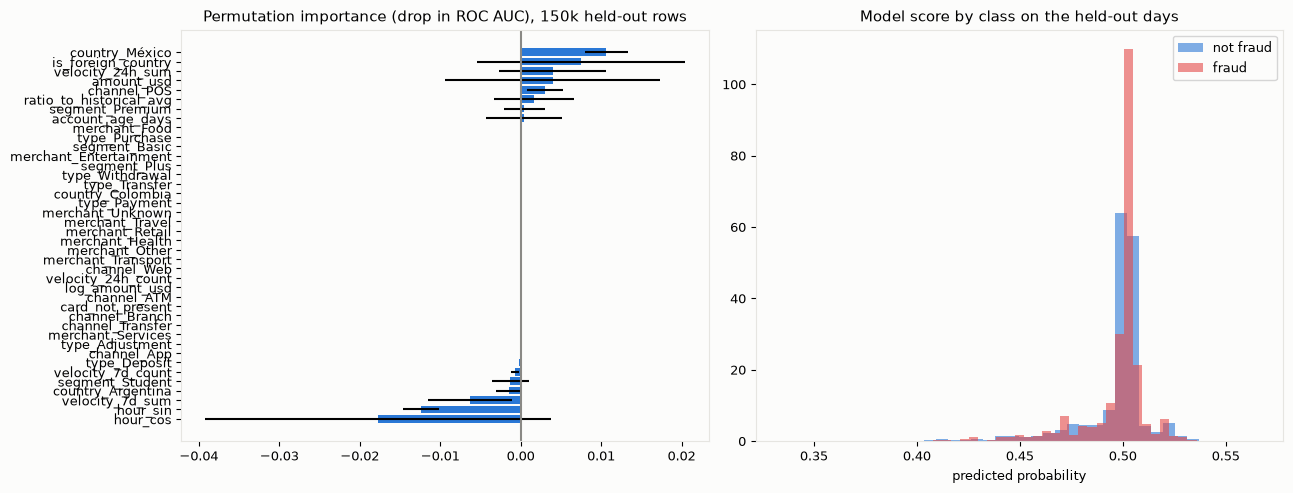

,feature,importance,std
27,country_México,0.01066,0.00270
7,is_foreign_country,0.00751,0.01288
3,velocity_24h_sum,0.00402,0.00665
0,amount_usd,0.00397,0.01341
12,channel_POS,0.00304,0.00225
6,ratio_to_historical_avg,0.00169,0.00494
30,segment_Premium,0.00047,0.00255
10,account_age_days,0.00043,0.00469
18,merchant_Food,0.00012,0.00002
34,type_Purchase,0.00000,0.00000


In [9]:
sub = test_df.sample(n=min(150_000, len(test_df)), random_state=7)
perm = permutation_importance(model, sub[FEATURES].to_numpy(), sub["is_fraud"].to_numpy(), scoring="roc_auc", n_repeats=2, random_state=7, n_jobs=-1)
imp = pd.DataFrame({"feature": FEATURES, "importance": perm.importances_mean, "std": perm.importances_std}).sort_values("importance", ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(imp["feature"][::-1], imp["importance"][::-1], xerr=imp["std"][::-1], color=BLUE); axes[0].axvline(0, color=GRAY); axes[0].set_title("Permutation importance (drop in ROC AUC), 150k held-out rows")
axes[1].hist(scores["gradient boosting"][y_te == 0], bins=40, density=True, alpha=0.6, color=BLUE, label="not fraud"); axes[1].hist(scores["gradient boosting"][y_te == 1], bins=40, density=True, alpha=0.6, color=RED, label="fraud")
axes[1].set_title("Model score by class on the held-out days"); axes[1].set_xlabel("predicted probability"); axes[1].legend()
plt.tight_layout(); plt.savefig("notebooks/09_risk_model_importance.png", dpi=120); plt.show()
imp.round(5).head(10)

## 7. Sanity check: the pipeline learns when a signal exists

To rule out a broken pipeline, the same features and the same model are trained on a synthetic label that does depend on behavior: a foreign, card-not-present charge over 1,000 USD is labeled fraud with probability 0.5, and every other row keeps the base rate. The model must recover it.

In [10]:
rng = np.random.default_rng(7)
pattern = (feats["is_foreign_country"] == 1.0) & (feats["card_not_present"] == 1.0) & (feats["amount_usd"] > 1000)
synthetic = np.where(pattern, rng.random(len(feats)) < 0.5, rng.random(len(feats)) < base_rate / 100).astype(int)
y_tr_s, y_te_s = synthetic[~is_test.to_numpy()], synthetic[is_test.to_numpy()]
model_s = HistGradientBoostingClassifier(max_iter=100, learning_rate=0.1, max_leaf_nodes=15, class_weight="balanced", random_state=7).fit(X_tr, y_tr_s)
s = model_s.predict_proba(X_te)[:, 1]
print(f"synthetic label: {y_te_s.sum()} positives on the test days; test ROC AUC {roc_auc_score(y_te_s, s):.3f}, PR AUC {average_precision_score(y_te_s, s):.3f}")
perm_s = permutation_importance(model_s, sub[FEATURES].to_numpy(), synthetic[sub.index], scoring="roc_auc", n_repeats=2, random_state=7, n_jobs=-1)
pd.DataFrame({"feature": FEATURES, "importance": perm_s.importances_mean}).sort_values("importance", ascending=False).head(6).round(4)

synthetic label: 5462 positives on the test days; test ROC AUC 0.869, PR AUC 0.372


,feature,importance
11,card_not_present,0.4129
0,amount_usd,0.3909
7,is_foreign_country,0.3407
8,hour_sin,0.0080
15,channel_App,0.0015
30,segment_Premium,0.0008


## 8. The model's score against the dataset's `fraud_score`, row by row

Same held-out transactions, two scores: the probability our binary classifier assigns (the "binomial score", from behavior only) and the `fraud_score` column the organizer shipped (0 to 100, here divided by 100). If the two carried related information they would move together; if the model's score were informative at all, the fraud rate would rise along its deciles the way it rises along the leak's.

held-out rows with a database score: 1,243,362 of 1,555,062
rank correlation (Spearman) between the two scores: -0.0002; Pearson: 0.0004


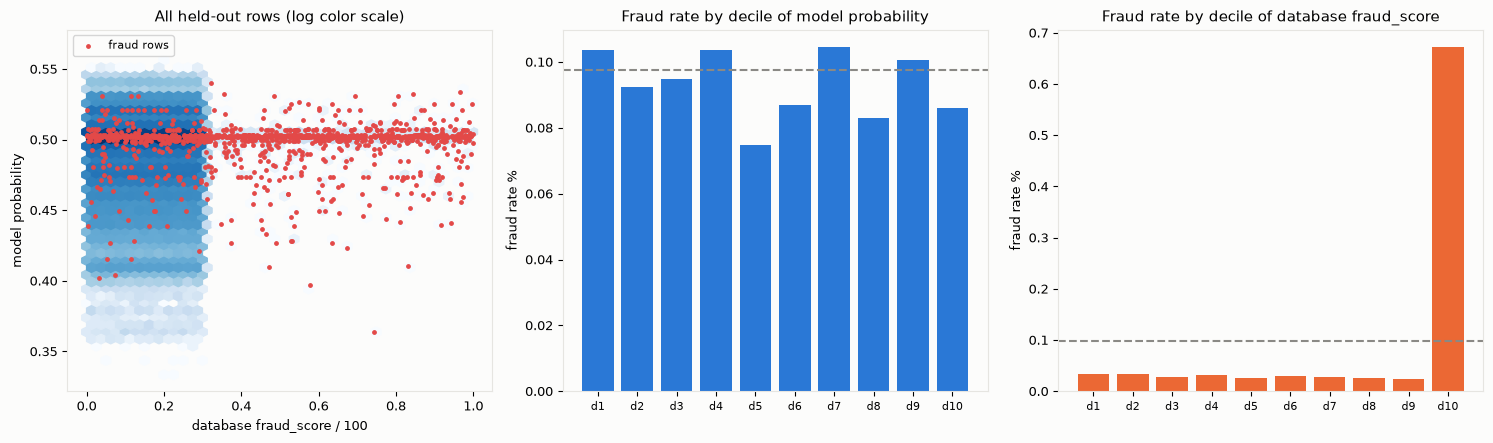

In [11]:
from scipy.stats import spearmanr, pearsonr
raw_db = leak_scores.reindex(test_df["transaction_id"]).to_numpy()  # NaN where the dataset has no score
cmp = pd.DataFrame({"model_score": scores["gradient boosting"], "db_fraud_score": raw_db, "is_fraud": y_te, "has_db_score": ~np.isnan(raw_db)})
both = cmp[cmp.has_db_score]  # the comparison uses only rows where both scores exist
rho, _ = spearmanr(both["model_score"], both["db_fraud_score"]); r, _ = pearsonr(both["model_score"], both["db_fraud_score"])
print(f"held-out rows with a database score: {len(both):,} of {len(cmp):,}")
print(f"rank correlation (Spearman) between the two scores: {rho:.4f}; Pearson: {r:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].hexbin(both["db_fraud_score"], both["model_score"], gridsize=40, bins="log", cmap="Blues"); axes[0].set_xlabel("database fraud_score / 100"); axes[0].set_ylabel("model probability"); axes[0].set_title("All held-out rows (log color scale)")
fr = both[both.is_fraud == 1]; axes[0].scatter(fr["db_fraud_score"], fr["model_score"], s=6, color=RED, label="fraud rows"); axes[0].legend(loc="upper left", fontsize=8)
# fraud rate by decile of each score (calibration view)
for ax, col, name in ((axes[1], "model_score", "model probability"), (axes[2], "db_fraud_score", "database fraud_score")):
    dec = pd.qcut(both[col].rank(method="first"), 10, labels=[f"d{i}" for i in range(1, 11)])
    rate = both.groupby(dec, observed=True)["is_fraud"].mean() * 100
    ax.bar(rate.index.astype(str), rate.values, color=BLUE if col == "model_score" else ORANGE); ax.axhline(base_rate, color=GRAY, ls="--")
    ax.set_title(f"Fraud rate by decile of {name}"); ax.set_ylabel("fraud rate %"); ax.tick_params(axis="x", labelsize=8)
plt.tight_layout(); plt.savefig("notebooks/10_model_vs_db_score.png", dpi=120); plt.show()

In [12]:
# Do the two scores flag the same rows? Top 1 percent of each, and the rows the leak marks as certain fraud (score above 30)
k = int(len(both) * 0.01)
top_model = set(both["model_score"].nlargest(k).index); top_db = set(both["db_fraud_score"].nlargest(k).index)
certain = both[both["db_fraud_score"] > 0.30]
summary = pd.DataFrame([
    {"set": "top 1% by model score", "rows": len(top_model), "fraud inside": int(both.loc[list(top_model), "is_fraud"].sum()), "fraud rate %": round(both.loc[list(top_model), "is_fraud"].mean() * 100, 3)},
    {"set": "top 1% by database fraud_score", "rows": len(top_db), "fraud inside": int(both.loc[list(top_db), "is_fraud"].sum()), "fraud rate %": round(both.loc[list(top_db), "is_fraud"].mean() * 100, 3)},
    {"set": "overlap of the two top 1% sets", "rows": len(top_model & top_db), "fraud inside": int(both.loc[list(top_model & top_db), "is_fraud"].sum()) if top_model & top_db else 0, "fraud rate %": round(both.loc[list(top_model & top_db), "is_fraud"].mean() * 100, 3) if top_model & top_db else 0.0},
    {"set": "database score above 30 (certain fraud by the leak)", "rows": len(certain), "fraud inside": int(certain["is_fraud"].sum()), "fraud rate %": round(certain["is_fraud"].mean() * 100, 3)},
])
expected_overlap = k * k / len(both)
print(f"overlap expected if the two rankings were independent: {expected_overlap:.0f} rows")
print(f"model probability on the leak's certain-fraud rows: mean {certain['model_score'].mean():.4f} against {both['model_score'].mean():.4f} on all rows; "
      f"their median rank by the model: {both['model_score'].rank(pct=True).loc[certain.index].median():.2f} (0.50 means no preference)")
summary

overlap expected if the two rankings were independent: 124 rows
model probability on the leak's certain-fraud rows: mean 0.4970 against 0.4975 on all rows; their median rank by the model: 0.47 (0.50 means no preference)


,set,rows,fraud inside,fraud rate %
0,top 1% by model score,12433,10,0.080
1,top 1% by database fraud_score,12433,803,6.459
2,overlap of the two top 1% sets,113,7,6.195
3,database score above 30 (certain fraud by the ...,798,798,100.000


Reading: the two scores are unrelated (rank correlation near zero, overlap of the top sets at the level chance predicts), the fraud rate is flat across the model's deciles while it climbs steeply in the top decile of the database score, and the rows the leak marks as certain fraud sit in the middle of the model's ranking. The model is not a worse version of the database score; it is measuring behavior that the label ignores, while the database score was written from the label.

## 9. Country, segment, tenure and transaction type: fraud proportion, model score and flags

Team request (27-Sep): these four variables are model inputs (country and segment as one-hot columns, tenure as `account_age_days`, transaction type as one-hot columns). For each value the table gives the rows on the held-out days, the proportion of fraud, the mean probability the model assigns, and the share of rows the model would flag at two operating points: the policy threshold of 0.70 (`POL-ESC-ML-RISK`) and the model's own top 1 percent. If the variable carried signal, the fraud proportion and the flagged share would rise together on the same values.

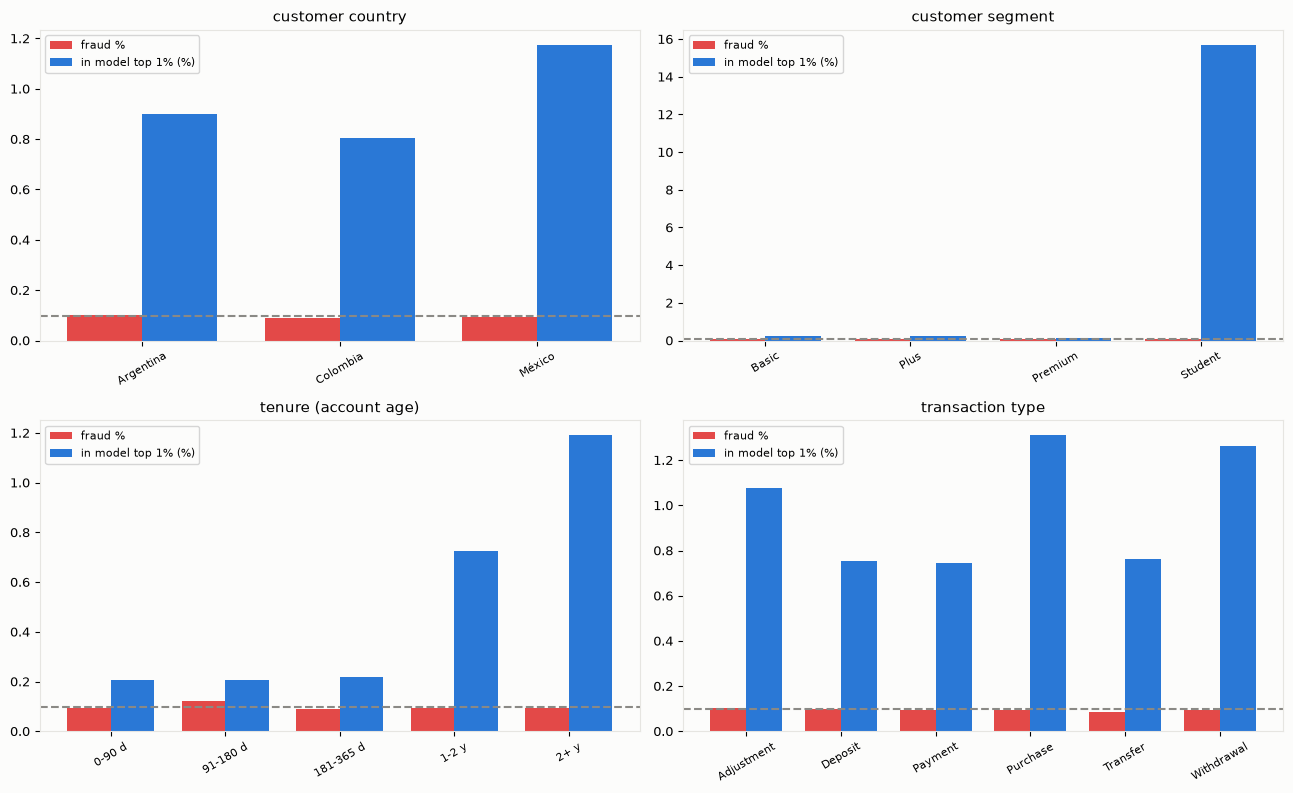

                    rows  fraud %  mean model score  flagged at 0.70 %  in model top 1% %
customer country                                                                         
Argentina         308924   0.1000            0.4970                0.0             0.9012
Colombia          466903   0.0906            0.4971                0.0             0.8032
México            779235   0.0915            0.4979                0.0             1.1759

                    rows  fraud %  mean model score  flagged at 0.70 %  in model top 1% %
customer segment                                                                         
Basic             931641   0.0922            0.4973                0.0             0.2525
Plus              390230   0.0984            0.4973                0.0             0.2583
Premium           155970   0.0827            0.4960                0.0             0.1314
Student            77221   0.0945            0.5037                0.0            15.7108

        

In [13]:
held = test_df.copy()
held["model_score"] = scores["gradient boosting"]
top1_cut = np.quantile(held["model_score"], 0.99)
tenure = pd.cut(held["account_age_days"], bins=[-1, 90, 180, 365, 730, 1e9], labels=["0-90 d", "91-180 d", "181-365 d", "1-2 y", "2+ y"])
views = {
    "customer country": held["country"].map(lambda c: {"Mexico": "México"}.get(c, c)),
    "customer segment": held["segment"],
    "tenure (account age)": tenure,
    "transaction type": held["transaction_type"],
}
tables = []
fig, axes = plt.subplots(2, 2, figsize=(13, 8)); axes = axes.ravel()
for ax, (name, key) in zip(axes, views.items()):
    g = held.groupby(key, observed=True)
    t = pd.DataFrame({"rows": g.size(), "fraud %": g["is_fraud"].mean() * 100, "mean model score": g["model_score"].mean(),
                      "flagged at 0.70 %": g["model_score"].apply(lambda s: (s >= 0.70).mean() * 100),
                      "in model top 1% %": g["model_score"].apply(lambda s: (s >= top1_cut).mean() * 100)})
    t.index.name = name; tables.append(t)
    x = np.arange(len(t)); w = 0.38
    ax.bar(x - w/2, t["fraud %"], w, color=RED, label="fraud %"); ax.bar(x + w/2, t["in model top 1% %"], w, color=BLUE, label="in model top 1% (%)")
    ax.axhline(base_rate, color=GRAY, ls="--"); ax.set_xticks(x); ax.set_xticklabels([str(i) for i in t.index], rotation=30, fontsize=8); ax.set_title(name); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("notebooks/15_country_segment_tenure_type.png", dpi=120); plt.show()
for t in tables:
    print(t.round(4).to_string()); print()

Reading: the fraud proportion barely moves across countries, segments, tenure bands and transaction types, and the model's mean score and flagged shares are essentially constant across them as well. With the policy threshold of 0.70 the model flags nothing anywhere (the cost-optimal behavior when scores carry no information); the top 1 percent is spread across all values in proportion to their size, not concentrated where fraud sits, because fraud does not sit anywhere in particular.

## 10. Conclusion

- The fraud label is flat along every variable the model may use (section 3), carries no measurable information (section 4), and the model sits at chance on the held-out days while the leaked score separates the classes (section 5). The model's scores for fraud and non-fraud overlap completely and no feature has an importance above noise (section 6).
- The pipeline itself learns a behavioral pattern when one exists (section 7), so the negative result is a property of the data, not of the code.
- Under the cost rule (a missed fraud costs 10 unnecessary verifications) the optimal threshold flags nothing, which is why `POL-ESC-ML-RISK` never fires with a calibrated score from this data.

Options recorded in TQ-023: report the negative result with this notebook as evidence (recommended); train the same pipeline on a proxy target with real structure if one is found; or keep the rules baseline as the risk signal and say why. Whatever the choice, the leak stays out of every model.